In [ ]:
import ROOT
import emm

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Get data
data_tree = emm.get_data(sort_and_index=True, tree=True)

x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 4000)
index=ROOT.RooRealVar("index", "index", 0, 0, 1e6)

data = ROOT.RooDataSet("data", "data", ROOT.RooArgSet(x, index), ROOT.RooFit.Import(data_tree))

# Initial Conditions

In [ ]:
pset = {
    'raw_rate_0': (0.3, 2.5, 50),
    'raw_rate_1': (0.3, 2.5, 50),
}

model = emm.ExponentialMixtureModel(x, 2, data_mean=data.mean(x))

df = emm.scan_parameters(
    model, data, pset,
    constant=False, # Not fixing parameters
    # use_condor=False, n_batches=8, cache_name="2D_grid_restarts", remake_cache=True,
    use_condor=True, n_batches=64, cache_name="2D_grid_restarts",# remake_cache=True,
)

fig, axes = emm.plot_pair_profiles(df, pset, plot_contours=False,)
print(f"Minimum NLL: {df['nll'].min()}")
print(f"Best fit parameters: {df.loc[df['nll'].idxmin()]}")

In [ ]:
# Plot the distribution of the NLL
fig, ax = plt.subplots()
m = df['nll'].min()
n, bins, patches = ax.hist(df['nll'], range=(m, m+0.001), bins=50, density=True)
ax.set_xlabel("NLL")
ax.set_ylabel("Density")

In [ ]:
pset = {
    'raw_rate_0': (0.3, 3, 40),
    'raw_rate_1': (0.3, 3, 40),
    'raw_rate_2': (0.3, 3, 40),
}

model = emm.ExponentialMixtureModel(x, 3, data_mean=data.mean(x))

df = emm.scan_parameters(
    model, data, pset,
    constant=False, # Not fixing parameters
    use_condor=True, n_batches=64, cache_name="3D_grid_restarts",# remake_cache=True,
)

fig, axes = emm.plot_pair_profiles(df, pset, plot_contours=False, worst_case=False)
print(f"Minimum NLL: {df['nll'].min()}")
print(f"Best fit parameters: {df.loc[df['nll'].idxmin()]}")

In [ ]:
# Plot the distribution of the NLL
fig, ax = plt.subplots()
m = df['nll'].min()
n, bins, patches = ax.hist(
    df['nll'],
    # range=(m, m+0.005),
    # range=(31090, 31100),
    bins=50,
    # density=True
)
ax.set_xlabel("NLL")
# ax.set_ylabel("Density")

# Does it matter if we get stuck in a local minimum?

In [ ]:
# Use toys to estimate the NLL uncertainty due to data statistics
best_initial = emm.get_initial(2)
worst_initial = emm.get_initial(2, worst_case=True)

model = emm.ExponentialMixtureModel(x, 2, data_mean=data.mean(x))
defaults = {param.GetName(): param.getVal() for param in model.params}

nll = model.pdf.createNLL(data)

# Get worst case nll
model.set_params(worst_initial)
model.pdf.fitTo(data)
nll_worst = model.pdf.createNLL(data)

# Gest best case nll
model.set_params(best_initial)
model.pdf.fitTo(data)
nll_best = model.pdf.createNLL(data)

# Generate toys and calculate the different in NLL between the best and worst initializations
n_toys = 100
nlls_global = []
nlls_local = []
for i in range(n_toys):
    toy = model.pdf.generate(ROOT.RooArgSet(x), data.numEntries())
    # nll = model.pdf.createNLL(toy)
    i_model = emm.ExponentialMixtureModel(x, 2, data_mean=data.mean(x))
    i_model.set_params(initials)
    nll = i_model.pdf.createNLL(toy)
    fit_result = model.pdf.fitTo(toy)
    nlls.append(nll.getVal())

In [ ]:
# Plot the distribution of the nlls and print some statistics
plt.hist(nlls, bins=10)
plt.xlabel("NLL")
plt.ylabel("Number of toys")
plt.title("NLL distribution from toys")
plt.show()
print(f"Mean NLL: {np.mean(nlls)}")
print(f"Std NLL: {np.std(nlls)}")

In [ ]:
initials = {
    'raw_rate_0': 1.295,
    'raw_rate_1': 0.584,
    'raw_rate_2': 1.579,
}

In [ ]:
model = emm.ExponentialMixtureModel(x, 3, data_mean=data.mean(x))
model.set_params(initials)
emm.fit_and_plot(model, data, x)

In [ ]:
# Add two events in the tail
data_copy = data.Clone()
# vals_to_add = [2500]*50
vals_to_add = np.random.normal(3800, 30, size=1)
for val in vals_to_add:
    x.setVal(val)
    index.setVal(data_copy.numEntries())
    data_copy.add(ROOT.RooArgSet(x, index))

print(f"Data entries (with tail events): {data_copy.numEntries()}")

In [ ]:
# model = emm.ExponentialMixtureModel(x, 3, data_mean=data_copy.mean(x))
models = [emm.ExponentialMixtureModel(x, k, data_mean=data_copy.mean(x)) for k in range(2, 5)]
model_labels = [f"{k} Mixtures" for k in range(2, 5)]
fit_results = [m.pdf.fitTo(data_copy, ROOT.RooFit.Save()) for m in models]
emm.plot_fits(data_copy, x, models, model_labels, fit_results,)
# model.set_params(initials)
# model.set_param('raw_rate_2', 0, constant=True)
# emm.fit_and_plot(model, data_copy, x)

In [ ]:
pset = {
    'raw_rate_0': (0.3, 3, 20),
    'raw_rate_1': (0.3, 3, 20),
}

def model_primitive(x, data):
    model = emm.ExponentialMixtureModel(x, 4, data_mean=data.mean(x), ordered_rates=True)
    return model

df = emm.profile_model(x, model_primitive, data, pset)
fig, axes = emm.plot_pair_profiles(df, pset, plot_contours=False,)

In [ ]:
model_2 = emm.ExponentialMixtureModel(x, 2, data_mean=data.mean(x), use_normalization_construction=True)
emm.fit_and_plot(model_2, data, x, minos=True)

In [ ]:
pset = {
    # 'raw_rate_0': (0.01, 5, 20),
    # 'raw_rate_1': (0.3, 2.5, 20),
    'raw_rate_2': (0.3, 5, 20),
    'raw_rate_3': (0.3, 5, 20)
}

model_2_params = {}
for i in range(model_2.n_components):
    r = model_2.raw_rates[i]
    r_nominal = r.getVal()
    r_up = r.getErrorHi()
    r_down = r.getErrorLo()
    model_2_params[f'raw_rate_{i}'] = (r_nominal, r_nominal-r_down, r_nominal+r_up)

def model_primitive(x, data):
    model = emm.ExponentialMixtureModel(x, 4, data_mean=data.mean(x), use_normalization_construction=True, **model_2_params)
    return model

df = emm.profile_model(x, model_primitive, data, pset)
fig, axes = emm.plot_pair_profiles(df, pset)

In [ ]:
#print the minimum
print("Minimum value of the model:", df['nll'].min())
print(f"Parameters at minimum: \n{df.loc[df['nll'].idxmin()]}")
    

In [ ]:
#print the minimum
print("Minimum value of the model:", df['nll'].min())
print(f"Parameters at minimum: \n{df.loc[df['nll'].idxmin()]}")

In [ ]:

grid = np.linspace(0, 10, 100)

def fit_model(supports):
    model = emm.ExponentialMixtureModel(x, len(supports), data_mean=data.mean(x), use_normalization_construction=True)
    for i, support in enumerate(supports):
        model.raw_rates[i].setVal(support)
        model.raw_rates[i].setConstant(True)
    
    model.pdf.fitTo(data)
    weights = [p.getVal() for p in model.weights]

    nll = model.pdf.createNLL(data)
    return {
        "nll": nll.getVal(),
        "weights": weights,
        "supports": supports
    }

# Randomly search through the parameter space, if a new nll is found 

In [ ]:
""

## Do retries help?

In the Dijet example I allow for a large number of retries (60-100) because these fits seem to fail more often. After retrying they usually succeed, but are these results even useful?

In [10]:
# Imports
import ROOT
import array

from tools import scale_out as so

from emm import data
from emm import fitting
from emm import models

import matplotlib.pyplot as plt
import numpy as np

In [22]:
# Load the data
h_obs, h_fit = data.get_dijet_data()

# Get binning from data
xaxis = h_obs.GetXaxis()
boundaries = [xaxis.GetBinLowEdge(i) for i in range(1, xaxis.GetNbins() + 2)]
binning = ROOT.RooBinning(len(boundaries) - 1, array.array('d', boundaries))

x = ROOT.RooRealVar("x", "Dijet Mass [GeV]", boundaries[0], boundaries[-1])
x.setBinning(binning)

dijet_data = ROOT.RooDataHist("ATLAS_dijet_data", "ATLAS dijet data", ROOT.RooArgList(x), h_obs)
print(f"Data mean: {dijet_data.mean(x)}")

# SW -- Dijet Paper Fit
dh_fit = ROOT.RooDataHist("dh_fit", "dh_fit", ROOT.RooArgList(x), h_fit)
pdf_fit = ROOT.RooHistPdf("pdf_fit", "pdf_fit", ROOT.RooArgSet(x), dh_fit)

fit_options = [
    ROOT.RooFit.IntegrateBins(0.001),
    ROOT.RooFit.PrintLevel(-1),
    # ROOT.RooFit.Offset(True),
    ROOT.RooFit.Strategy(2),
    ROOT.RooFit.Save(),
    # ROOT.RooFit.Range("fit_range")
]

Data mean: 1347.5082817871998


Warning in <TROOT::Append>: Replacing existing TH1: h_observed (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_fit (Potential memory leak).


In [26]:
# Fit the dijet function with different precisions
import time

for prec in [0.1, 0.001, 0.00001]:
    print(f"Fitting with precision: {prec}")
    default_fit_options = [
        ROOT.RooFit.IntegrateBins(prec),
        ROOT.RooFit.PrintLevel(-1),
        # ROOT.RooFit.Offset(True),
        # ROOT.RooFit.Strategy(2),
        ROOT.RooFit.Save(),
    ]

    t1 = time.time()
    dijet_model = models.Dijet(x)
    fit_result = dijet_model.pdf.fitTo(dijet_data, *default_fit_options)
    t2 = time.time()
    print(f"Fit results, NLL: {fit_result.minNll()} Time taken: {t2 - t1:.2f} seconds")


Fitting with precision: 0.1
Fit results, NLL: 186084288.12499446 Time taken: 10.08 seconds
Fitting with precision: 0.001
Fit results, NLL: 186084288.12499446 Time taken: 9.68 seconds
Fitting with precision: 1e-05
Fit results, NLL: 186084288.12499446 Time taken: 10.01 seconds
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using nu

In [23]:
# Fit random restarts
all_results = fitting.fit_random_restarts(
    x, dijet_data,
    models.ModelPrimitive(
        models.ExponentialMixtureModel,
        4,
        data_mean=1347,
        name="ExponentialMixture-4"
    ),
    seed=1234,
    n_restarts=100,
    n_retries=100,
    save=False,
    return_all_results=True,
    fit_options=fit_options
)

[#[#1] 1INFO] :MinimizationINFO -- :RooAbsMinimizerFcn::setOptimizeConst: activating const optimizationMinimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#[#11] ] INFOINFO::MinimizationMinimization --  --  The following expressions will be evaluated in cache-and-track mode:  The following expressions will be evaluated in cache-and-track mode: ((pdf_0pdf_0,,pdf_1pdf_1,,pdf_2pdf_2,,pdf_3pdf_3)
)
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (pdf_0,pdf_1,pdf_2,pdf_3)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated

Warning in <Minuit2>: VariableMetricBuilder No improvement in line search
Warning in <Minuit2>: VariableMetricBuilder Edm is limited by Machine accuracy - return current minimum
Warning in <Minuit2>: VariableMetricBuilder No convergence; Edm 0.0326459 is above tolerance 0.01
Warning in <Minuit2>: Minuit2Minimizer::Minimize Minimization did NOT converge, Edm is above max
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.0346213
Warning in <Minuit2>: VariableMetricBuilder No improvement in line search
Warning in <Minuit2>: VariableMetricBuilder Edm is limited by Machine accuracy - return current minimum
Warning in <Minuit2>: VariableMetricBuilder No convergence; Edm 0.0153443 is above tolerance 0.01
Warning in <Minuit2>: Minuit2Minimizer::Minimize Minimization did NOT converge, Edm is above max
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.0346164
Warning in <Minuit2>: VariableMetricBuilder No improvement in line search
Warning in

In [24]:
# Print results
min_nll = min([r['nll'] for r in all_results if r is not None])
for i, result in enumerate(all_results):
    if result is None:
        continue
    # print(result)
    print(f"Fit {i}: Delta NLL = {result['nll'] - min_nll}, Status = {result['status']}, n_retries = {result['n_retries']}")

Fit 0: Delta NLL = 19.338681370019913, Status = 0, n_retries = 88
Fit 2: Delta NLL = 16.994832575321198, Status = 0, n_retries = 10
Fit 3: Delta NLL = 19.250683933496475, Status = 0, n_retries = 1
Fit 6: Delta NLL = 44.48823198676109, Status = 0, n_retries = 23
Fit 7: Delta NLL = 16.880287766456604, Status = 1, n_retries = 2
Fit 8: Delta NLL = 22.248368084430695, Status = 0, n_retries = 2
Fit 10: Delta NLL = 2.0056906044483185, Status = 0, n_retries = 4
Fit 13: Delta NLL = 10.482656300067902, Status = 0, n_retries = 4
Fit 16: Delta NLL = 20.374923795461655, Status = 0, n_retries = 2
Fit 17: Delta NLL = 19.921571522951126, Status = 1, n_retries = 9
Fit 19: Delta NLL = 253.0982813835144, Status = 0, n_retries = 12
Fit 21: Delta NLL = 0.0, Status = 0, n_retries = 3
Fit 24: Delta NLL = 14.908679574728012, Status = 0, n_retries = 3
Fit 25: Delta NLL = 2.5453279614448547, Status = 0, n_retries = 11
Fit 32: Delta NLL = 1.0303784012794495, Status = 0, n_retries = 32
Fit 33: Delta NLL = 12.8509

In [7]:
# Print results
min_nll = min([r['nll'] for r in all_results if r is not None])
for i, result in enumerate(all_results):
    if result is None:
        continue
    # print(result)
    print(f"Fit {i}: Delta NLL = {result['nll'] - min_nll}, Status = {result['status']}, n_retries = {result['n_retries']}")

Fit 0: Delta NLL = 16.639023154973984, Status = 0, n_retries = 2
Fit 1: Delta NLL = 15.081883251667023, Status = 0, n_retries = 1
Fit 6: Delta NLL = 8.150632470846176, Status = 0, n_retries = 7
Fit 7: Delta NLL = 17.5060493350029, Status = 0, n_retries = 0
Fit 11: Delta NLL = 0.4472193717956543, Status = 0, n_retries = 1
Fit 13: Delta NLL = 45.88357663154602, Status = 0, n_retries = 8
Fit 18: Delta NLL = 60.974960058927536, Status = 0, n_retries = 4
Fit 19: Delta NLL = 18.119718313217163, Status = 0, n_retries = 2
Fit 25: Delta NLL = 0.0, Status = 1, n_retries = 4
Fit 26: Delta NLL = 17.75476774573326, Status = 0, n_retries = 11
Fit 28: Delta NLL = 20.4377039372921, Status = 0, n_retries = 1
Fit 30: Delta NLL = 15.466610878705978, Status = 0, n_retries = 4
Fit 32: Delta NLL = 17.39693996310234, Status = 0, n_retries = 2
Fit 35: Delta NLL = 46.18212565779686, Status = 0, n_retries = 4
Fit 40: Delta NLL = 18.99011093378067, Status = 0, n_retries = 3
Fit 49: Delta NLL = 16.570692539215088

33 good fits


Text(0, 0.5, 'Delta NLL')

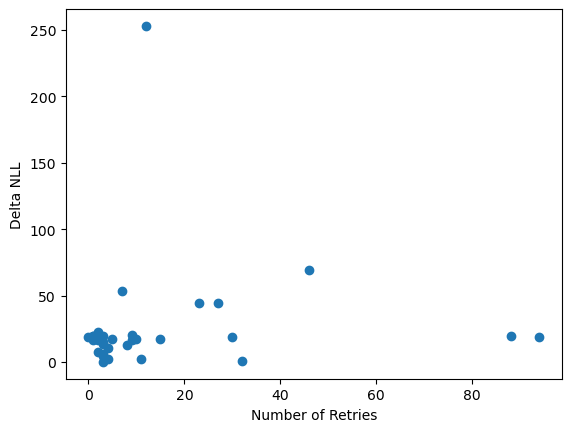

In [27]:
# Plot delta NLL vs. n_retries
delta_nlls = []
n_retries = []
for r in all_results:
    if r is None:
        continue
    delta_nlls.append(r['nll']-min_nll)
    n_retries.append(r['n_retries'])

print(f"{len(delta_nlls)} good fits")
fig, ax = plt.subplots()
ax.scatter(n_retries, delta_nlls)
ax.set_xlabel("Number of Retries")
ax.set_ylabel("Delta NLL")